# Calculate Long and Short Range Electrostatic Interactions

Change variables "nosalt_type_sims" and "salt_bound_sims" to include .dat files for each type

Change variables "num_bound_sims" and "num_bound_salt_sims" to be number of simulations

testing change

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import glob
%matplotlib inline

In [2]:
# #cutoff for electrostat contact

long = 10
short = 4

# #making empty lists to put contact files in
nosalt_type_sims = []

In [3]:
#loading in all electrostat files from ArkA12 nosalt_bound and nosalt_bound sims
nosalt_type_sims = glob.glob('/data/amujica/ArkA12_bound/analysis/long_range_electrostatic_interactions/dat/*.dat')
salt_bound_sims = glob.glob('/data/jcardoso/ArkA12_bound_salt/analysis/long_range_electrostatic_interactions/dat/*.dat')

## nosalt_type_sims

### ADD NO SALT LONG AND SHORT TO DATAFRAME

In [8]:
#define number of independent sims for bound sims
num_bound_sims = 10
#make dataframes for the fraction of electrostats and for the sem of that
electrostat_frac = pd.DataFrame(columns=['nosalt sims long', 'nosalt sims short', 'salt sims long', 'salt sims short'])
electrostat_frac_sem = pd.DataFrame(columns=['nosalt sims long', 'nosalt sims short', 'salt sims long', 'salt sims short'])
#make dataframe for total electrostat frac for each independent bound sim 
total_electrostat_frac_bound = pd.DataFrame(0, columns=['nosalt sims long', 'nosalt sims short', 'salt sims long', 'salt sims short'], index = range(0,num_bound_sims))


#less than contact_dist and bound sims
for file_name in nosalt_type_sims:
    df_bound = pd.read_table(file_name, sep = '\s+')
    df_bound = df_bound.drop(['#Frame'], axis=1)
    df_bound.columns = ['distance']

    ### NOSALT SIMS LONG ###
    #calculate mean for for each contact over all independent sims
    electrostat_frac.loc[file_name.split('/')[-1],
                     'nosalt sims long'] = np.mean((df_bound['distance'] < long) & (df_bound['distance'] > short))
#     print(df_bound['distance'].min())
    #calculate number of frames in one simulation
    num_bound_snapshots = int(len(df_bound)/num_bound_sims)

    frac_by_sim = pd.DataFrame(columns=['nosalt sims long'])
    #for each independent sim, calculate the mean for each contact
    for sim in range(0,num_bound_sims):
        df_sim = df_bound[sim*num_bound_snapshots:(sim+1)*num_bound_snapshots]
        # Condition for long-range encounters in each simulation (formerly less_than_10_encounter_sim)
        short_range_bound_sim = ((df_sim['distance'] < short))
        # Calculate total encounters in this simulation
        num_contacts_bound_sim = short_range_bound_sim.sum()
     # Store the fraction for the current simulation
        frac_sim = num_contacts_bound_sim / (len(df_bound)/num_bound_sims)
        sim_fractions.append(frac_sim)

        electrostat_frac.loc[file_name.split('/')[-1],
                     'wildtype short'] = np.mean((df_bound['distance'] < short))
# Update the total electrostat fraction for the binding simulations
        total_electrostat_frac_bound.loc[sim, 'wildtype short'] += frac_sim
        # frac_by_sim = frac_by_sim.append({'nosalt sims long': 
        #         np.mean((df_bound[sim*num_bound_snapshots:
        #         (sim+1)*num_bound_snapshots]['distance']
        #                 < long) & (df_bound[sim*num_bound_snapshots:
        #         (sim+1)*num_bound_snapshots]['distance']
        #                 > short))},ignore_index=True)
        # total_electrostat_frac_bound.loc[sim,'nosalt sims long'] += np.mean((df_bound[sim*num_bound_snapshots:
        #         (sim+1)*num_bound_snapshots]['distance']
        #                 < long) & (df_bound[sim*num_bound_snapshots:
        #         (sim+1)*num_bound_snapshots]['distance']
        #                 > short))
    electrostat_frac_sem.loc[file_name.split('/')[-1],'nosalt sims long'] = frac_by_sim.sem()['nosalt sims long']
    
    ### NOSALT SIMS SHORT ###
    electrostat_frac.loc[file_name.split('/')[-1],
                     'nosalt sims short'] = np.mean(df_bound['distance'] < short)
#     print(df_bound['distance'].min())
    #calculate number of frames in one simulation
    num_bound_snapshots = int(len(df_bound)/num_bound_sims)

    frac_by_sim = pd.DataFrame(columns=['nosalt sims short'])
    #for each independent sim, calculate the mean for each contact
    for sim in range(0,num_bound_sims):
        frac_by_sim = frac_by_sim.append({'nosalt sims short': 
                np.mean(df_bound[sim*num_bound_snapshots:
                (sim+1)*num_bound_snapshots]['distance']
                        < short)},ignore_index=True)
        total_electrostat_frac_bound.loc[sim,'nosalt sims short'] += np.mean(df_bound[sim*num_bound_snapshots:
                (sim+1)*num_bound_snapshots]['distance']
                        < short)
    electrostat_frac_sem.loc[file_name.split('/')[-1],'nosalt sims short'] = frac_by_sim.sem()['nosalt sims short']

electrostat_frac

TypeError: cannot concatenate object of type '<class 'numpy.float64'>'; only Series and DataFrame objs are valid

## 800 mM_salt_sims

### ADD 800 mM SALT LONG AND SHORT TO DATAFRAME

In [5]:
#define number of independent sims for binding sims
num_bound_salt_sims = 10
#make dataframe for total electrostat frac for each independent binding sim
total_electrostat_frac_bound_salt = pd.DataFrame(0, columns=['nosalt sims long', 'nosalt sims short', 'salt sims long', 'salt sims short'], index = range(0,num_bound_salt_sims))




#less than contact_dist and bound sims
for file_name in salt_bound_sims:
    df_bound_salt = pd.read_table(file_name, sep = '\s+')


    df_bound_salt = df_bound_salt.drop(['#Frame'], axis=1)
    df_bound_salt.columns = ['distance']

    ### SALT SIMS LONG ###
    #calculate mean for for each contact over all independent sims
    electrostat_frac.loc[file_name.split('/')[-1],
                     'salt sims long'] = np.mean((df_bound_salt['distance'] < long) & (df_bound_salt['distance'] > short))
    #calculate standard deviation
    num_bound_snapshots = int(len(df_bound_salt)/num_bound_salt_sims)


    frac_by_sim = pd.DataFrame(columns=['salt sims long'])
    #for each independent sim, calculate the mean for each contact
    for sim in range(0,num_bound_salt_sims):
        frac_by_sim = frac_by_sim.append({'salt sims long': 
                np.mean((df_bound_salt[sim*num_bound_snapshots:
                (sim+1)*num_bound_snapshots]['distance']
                        < long) & (df_bound_salt[sim*num_bound_snapshots:
                (sim+1)*num_bound_snapshots]['distance']
                        > short))},ignore_index=True)
        total_electrostat_frac_bound.loc[sim,'salt sims long'] += np.mean((df_bound_salt[sim*num_bound_snapshots:
                (sim+1)*num_bound_snapshots]['distance'] < long) & (df_bound_salt[sim*num_bound_snapshots:
                (sim+1)*num_bound_snapshots]['distance'] > short))
    electrostat_frac_sem.loc[file_name.split('/')[-1],'salt sims long'] = frac_by_sim.sem()['salt sims long']

    ### SALT SIMS SHORT ###
    #calculate mean for for each contact over all independent sims
    electrostat_frac.loc[file_name.split('/')[-1],
                     'salt sims short'] = np.mean(df_bound_salt['distance'] 
                                             < short)
    #calculate standard deviation
    num_bound_snapshots = int(len(df_bound_salt)/num_bound_salt_sims)


    frac_by_sim = pd.DataFrame(columns=['salt sims short'])
    #for each independent sim, calculate the mean for each contact
    for sim in range(0,num_bound_salt_sims):
        frac_by_sim = frac_by_sim.append({'salt sims short': 
                np.mean(df_bound_salt[sim*num_bound_snapshots:
                (sim+1)*num_bound_snapshots]['distance']
                        < short)},ignore_index=True)
        total_electrostat_frac_bound.loc[sim,'salt sims short'] += np.mean(df_bound_salt[sim*num_bound_snapshots:
                (sim+1)*num_bound_snapshots]['distance']
                        < short)
    electrostat_frac_sem.loc[file_name.split('/')[-1],'salt sims short'] = frac_by_sim.sem()['salt sims short']

electrostat_frac

,nosalt sims long,nosalt sims short,salt sims long,salt sims short
D9_K60.dat,0.337992,0.646065,0.617058,0.36596
D11_K60.dat,0.912509,0.0555171,0.906887,0.0517008
D15_K60.dat,1.79167e-05,0,0.000492917,0
D24_K60.dat,4.58333e-06,0,0,0
D33_K60.dat,5e-06,0,0,0
D34_K60.dat,1.375e-05,0,8.33333e-07,0
D35_K60.dat,0.000104583,0,1.29167e-05,0
D44_K60.dat,0,0,0,0
E7_K60.dat,0.00958917,0.00127833,0.00377875,0.000317917
E14_K60.dat,3.25e-05,0,0.00014375,0


## TOTAL ELECTROSTATIC INTERATIONS CHART

In [6]:
total_electrostat_frac_bound

,nosalt sims long,nosalt sims short,salt sims long,salt sims short
0,4.324804,2.350587,4.094029,1.888312
1,4.119988,2.255704,3.956442,1.342900
2,4.295754,2.279829,3.912175,1.270346
3,4.023192,2.130612,4.268550,1.789029
4,4.107846,1.627438,4.109250,1.734546
5,4.300017,2.004300,3.897296,1.416475
6,4.230512,1.990983,4.183529,1.851492
7,4.138013,2.290621,4.190892,1.821492
8,3.968392,2.148942,4.157108,1.740487
9,4.172363,2.366575,4.108042,1.784729


In [7]:
#calcs amount of contacts occuring on average at any given time
total_electrostat_frac_bound.mean()

nosalt sims long     4.168088
nosalt sims short    2.144559
salt sims long       4.087731
salt sims short      1.663981
dtype: float64

In [8]:
#calculating sem for average at any given time for bound sims
total_electrostat_frac_bound.sem()

nosalt sims long     0.037991
nosalt sims short    0.071072
salt sims long       0.039800
salt sims short      0.072315
dtype: float64

Text(0.5, 1.0, 'ArkA12 Bound')

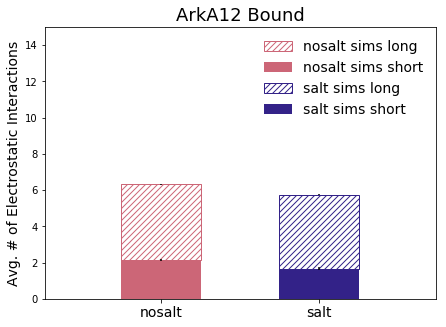

In [9]:
x = np.arange(1)  # X coordinates for each group
#print(x)
width = 0.41

plt.figure(figsize=(7,5))
#ax = total_electrostat_frac_bound.mean().plot.bar(yerr=total_electrostat_frac_bound.sem(), width=0.5, rot=45)
#fig = plt.gcf()
#ax.set_ylabel('Avg. # Electrostatic Interactions')
#plt.bar(x - width/2, total_electrostat_frac_bound.mean(), width, 
        #yerr=total_electrostat_frac_bound.sem())
    
# Plotting the "long" bars (only for "nosalt sims")
plt.bar(x - width/2 - 0.2, total_electrostat_frac_bound['nosalt sims long'].mean(), width, 
        bottom=total_electrostat_frac_bound['nosalt sims short'].mean(), edgecolor='#CC6677', facecolor='none', hatch='////', 
        yerr=total_electrostat_frac_bound['nosalt sims long'].sem(), label='nosalt sims long')

# Plotting the "short" bars (only for "nosalt sims")
plt.bar(x - width/2 - 0.2, total_electrostat_frac_bound['nosalt sims short'].mean(), width, color='#CC6677',
        yerr=total_electrostat_frac_bound['nosalt sims short'].sem(), label='nosalt sims short')

# Plotting the "long" bars (only for "salt sims")
plt.bar(x + width/2 + 0.2, total_electrostat_frac_bound['salt sims long'].mean(), width, 
        bottom=total_electrostat_frac_bound['salt sims short'].mean(), edgecolor='#332288', facecolor='none', hatch='////', 
        yerr=total_electrostat_frac_bound['salt sims long'].sem(), label='salt sims long')

# Plotting the "short" bars (only for "salt sims")
plt.bar(x + width/2 + 0.2, total_electrostat_frac_bound['salt sims short'].mean(), width, color='#332288',
        yerr=total_electrostat_frac_bound['salt sims short'].sem(), label='salt sims short')

plt.xlim(-1,1)
plt.ylim(0,15)
# Set x-axis ticks as original index
plt.xticks([-width/2 - 0.2, width/2 + 0.2], ["nosalt", "salt"], fontsize=14)

# Add legend, xlabel, ylabel, and title
plt.legend(fontsize=14, frameon=False)          
plt.ylabel('Avg. # of Electrostatic Interactions', fontsize=14)
plt.title('ArkA12 Bound', fontsize=18)

## Calculate p-values for avg plot

In [10]:
# ArkA12 bound effect of NaCl (JUST LONG)
ArkA12_avg_hb_values = np.concatenate([total_electrostat_frac_bound["nosalt sims long"].dropna().values,
                                           total_electrostat_frac_bound["salt sims long"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA12_long = (total_electrostat_frac_bound.mean()["nosalt sims long"])\
        - (total_electrostat_frac_bound.mean()["salt sims long"])\

print("ArkA12 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA12_long)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12_samples = [0]*numsample
diff_ArkA12_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12_samples)):
    random_groups = np.random.permutation(ArkA12_avg_hb_values)
    diff_ArkA12_samples[sample] = (np.mean(random_groups[0:num_bound_sims]) 
             - np.mean(random_groups[num_bound_sims:num_bound_sims 
                                                + num_bound_salt_sims]))
    if diff_ArkA12_samples[sample] >= diff_ArkA12_long:
        diff_ArkA12_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12 = (1 + np.sum(diff_ArkA12_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12)

ArkA12 bound 800 mM NaCl vs no-salt difference =  0.08035666666666597
p-value =  0.08189181081891811


In [11]:
# ArkA12 bound effect of NaCl (JUST SHORT)
ArkA12_avg_hb_values = np.concatenate([total_electrostat_frac_bound["nosalt sims short"].dropna().values,
                                           total_electrostat_frac_bound["salt sims short"].dropna().values])
#calculate the real difference, no salt minus salt
diff_ArkA12_short = total_electrostat_frac_bound.mean()["nosalt sims short"] - total_electrostat_frac_bound.mean()["salt sims short"]

print("ArkA12 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA12_short)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12_samples = [0]*numsample
diff_ArkA12_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12_samples)):
    random_groups = np.random.permutation(ArkA12_avg_hb_values)
    diff_ArkA12_samples[sample] = (np.mean(random_groups[0:num_bound_sims]) 
             - np.mean(random_groups[num_bound_sims:num_bound_sims 
                                                + num_bound_salt_sims]))
    if diff_ArkA12_samples[sample] >= diff_ArkA12_short:
        diff_ArkA12_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12 = (1 + np.sum(diff_ArkA12_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12)

ArkA12 bound 800 mM NaCl vs no-salt difference =  0.48057833333333333
p-value =  0.00019998000199980003


In [12]:
# ArkA12 bound effect of NaCl (TOTAL)
total_nosalt = total_electrostat_frac_bound["nosalt sims short"].dropna().values + total_electrostat_frac_bound["nosalt sims long"].dropna().values
total_salt = total_electrostat_frac_bound["salt sims short"].dropna().values + total_electrostat_frac_bound["salt sims long"].dropna().values
ArkA12_avg_hb_values = np.concatenate([total_nosalt, total_salt])

#calculate the real difference, no salt minus salt
diff_ArkA12_total = total_nosalt.mean() - total_salt.mean()

print("ArkA12 bound 800 mM NaCl vs no-salt difference = " , diff_ArkA12_total)

#sample 10000 times and calculate differences
numsample = 10000
diff_ArkA12_samples = [0]*numsample
diff_ArkA12_samples_larger = [0]*numsample
for sample in range(0,len(diff_ArkA12_samples)):
    random_groups = np.random.permutation(ArkA12_avg_hb_values)
    diff_ArkA12_samples[sample] = (np.mean(random_groups[0:num_bound_sims]) 
             - np.mean(random_groups[num_bound_sims:num_bound_sims 
                                                + num_bound_salt_sims]))
    if diff_ArkA12_samples[sample] >= diff_ArkA12_total:
        diff_ArkA12_samples_larger[sample] = 1

#calculate p-value
pval_diff_ArkA12 = (1 + np.sum(diff_ArkA12_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff_ArkA12)

ArkA12 bound 800 mM NaCl vs no-salt difference =  0.5609349999999997
p-value =  0.00029997000299970003


In [13]:
#cutoff for important contacts b/c don't need ones w/o important role 
frac_cutoff = 0.1 
common = pd.DataFrame(columns=['nosalt sims', 'Salt sims'])
common['nosalt sims'] = electrostat_frac.iloc[:,0:2].sum(axis=1) > frac_cutoff
common['Salt sims'] = electrostat_frac.iloc[:,2:4].sum(axis=1) > frac_cutoff

In [14]:
#making it so only those that meet cutoff show
electrostat_frac['important'] = common.any(axis = 1)
electrostat_frac_subset = electrostat_frac[electrostat_frac['important']]

#did same as above but for sem
electrostat_frac_sem['important'] = common.any(axis = 1)
electrostat_frac_sem_subset = electrostat_frac_sem[electrostat_frac_sem['important']]

In [15]:
electrostat_frac_sem

,nosalt sims long,nosalt sims short,salt sims long,salt sims short,important
D9_K60.dat,0.0310844,0.0357983,0.0250353,0.0260988,True
D11_K60.dat,0.0100659,0.00755848,0.010657,0.00981318,True
D15_K60.dat,8.40364e-06,0,0.000476894,0,False
D24_K60.dat,3.75e-06,0,0,0,False
D33_K60.dat,5e-06,0,0,0,False
D34_K60.dat,1.375e-05,0,8.33333e-07,0,False
D35_K60.dat,6.21206e-05,0,8.52669e-06,0,False
D44_K60.dat,0,0,0,0,False
E7_K60.dat,0.00543708,0.000852834,0.00244777,0.000317917,False
E14_K60.dat,2.20899e-05,0,0.000115906,0,False


In [16]:
electrostat_frac_subset

,nosalt sims long,nosalt sims short,salt sims long,salt sims short,important
D9_K60.dat,0.337992,0.646065,0.617058,0.36596,True
D11_K60.dat,0.912509,0.0555171,0.906887,0.0517008,True
E22_K60.dat,0.75234,9.66667e-05,0.578392,7.91667e-06,True
D15_K66.dat,0.545404,0,0.431514,7.08333e-06,True
E14_K66.dat,0.510565,0.471202,0.632659,0.324726,True
E17_K66.dat,0.115229,0.882402,0.118278,0.875308,True
D15_K71.dat,0.134991,0.00903292,0.0876354,0.00251833,True
E14_K71.dat,0.465354,0.0609004,0.39277,0.0367329,True
E17_K71.dat,0.200669,0.00165292,0.150127,0.00078875,True


In [17]:
#For Fractions
# #renaming so not file names and ArkA comes first
electrostat_frac_subset_rn = electrostat_frac_subset.rename(index={"E22_K60.dat": "K(3) to E22", 
                                                            "D15_K71.dat": "K(-8) to D15", 
                                                            "E17_K66.dat": "K(-3) to E17 ", 
                                                            "D33_K66.dat": "K(-3) to D33", 
                                                            "D11_K66.dat": "K(-3) to D11", 
                                                            "D9_K60.dat": "K(3) to D9", 
                                                            "D34_K66.dat": "K(-3) to D34", 
                                                            "E7_K71.dat": "K(-8) to E7", 
                                                            "D33_K71.dat": "K(-8) to D33", 
                                                            "E17_K71.dat": "K(-8) to E17", 
                                                            "D34_K71.dat": "K(-8) to D34", 
                                                            "E14_K71.dat": "K(-8) to E14", 
                                                            "D9_K66.dat": "K(-3) to D9", 
                                                            "E7_K60.dat": "K(3) to E7", 
                                                            "D15_K66.dat": "K(-3) to D15", 
                                                            "E22_K66.dat": "K(-3) to E22", 
                                                            "D35_K66.dat": "K(-3) to D35", 
                                                            "E22_K71.dat": "K(-8) to E22", 
                                                            "D9_K71.dat": "K(-8) to D9", 
                                                            "E7_K66.dat": "K(-3) to E7", 
                                                            "D35_K71.dat": "K(-8) to D35", 
                                                            "E14_K66.dat": "K(-3) to E14", 
                                                            "E17_K60.dat": "K(3) to E17", 
                                                            "E14_K60.dat": "K(3) to E14", 
                                                            "D11_K60.dat": "K(3) to D11"})
#rearranging index so in order of ArkA12 and then within that increasing of SH3
electrostat_frac_subset_rn = electrostat_frac_subset_rn.reindex(["K(3) to D9", 
                                                       "K(3) to D11",
                                                       "K(3) to E7",
                                                       "K(3) to E14", 
                                                       "K(3) to E17", 
                                                       "K(3) to E22",
                                                       "K(-3) to D9",
                                                       "K(-3) to D11",
                                                       "K(-3) to D15", 
                                                       "K(-3) to D33", 
                                                       "K(-3) to D34", 
                                                       "K(-3) to D35", 
                                                       "K(-3) to E7", 
                                                       "K(-3) to E14",
                                                       "K(-3) to E17 ",
                                                       "K(-3) to E22",
                                                       "K(-8) to D9",
                                                       "K(-8) to D15",
                                                       "K(-8) to D33",
                                                       "K(-8) to D34",
                                                       "K(-8) to D35",
                                                       "K(-8) to E7",
                                                       "K(-8) to E14",
                                                       "K(-8) to E17", 
                                                       "K(-8) to E22"])
electrostat_frac_subset_rn = electrostat_frac_subset_rn.dropna(axis=0)

In [18]:
#For Fractions
# #renaming so not file names and ArkA comes first
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset.rename(index={"E22_K60.dat": "K(3) to E22", 
                                                            "D15_K71.dat": "K(-8) to D15", 
                                                            "E17_K66.dat": "K(-3) to E17 ", 
                                                            "D33_K66.dat": "K(-3) to D33", 
                                                            "D11_K66.dat": "K(-3) to D11", 
                                                            "D9_K60.dat": "K(3) to D9", 
                                                            "D34_K66.dat": "K(-3) to D34", 
                                                            "E7_K71.dat": "K(-8) to E7", 
                                                            "D33_K71.dat": "K(-8) to D33", 
                                                            "E17_K71.dat": "K(-8) to E17", 
                                                            "D34_K71.dat": "K(-8) to D34", 
                                                            "E14_K71.dat": "K(-8) to E14", 
                                                            "D9_K66.dat": "K(-3) to D9", 
                                                            "E7_K60.dat": "K(3) to E7", 
                                                            "D15_K66.dat": "K(-3) to D15", 
                                                            "E22_K66.dat": "K(-3) to E22", 
                                                            "D35_K66.dat": "K(-3) to D35", 
                                                            "E22_K71.dat": "K(-8) to E22", 
                                                            "D9_K71.dat": "K(-8) to D9", 
                                                            "E7_K66.dat": "K(-3) to E7", 
                                                            "D35_K71.dat": "K(-8) to D35", 
                                                            "E14_K66.dat": "K(-3) to E14", 
                                                            "E17_K60.dat": "K(3) to E17", 
                                                            "E14_K60.dat": "K(3) to E14", 
                                                            "D11_K60.dat": "K(3) to D11"})
#rearranging index so in order of ArkA12 and then within that increasing of SH3
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset_rn.reindex(["K(3) to D9", 
                                                       "K(3) to D11",
                                                       "K(3) to E7",
                                                       "K(3) to E14", 
                                                       "K(3) to E17", 
                                                       "K(3) to E22",
                                                       "K(-3) to D9",
                                                       "K(-3) to D11",
                                                       "K(-3) to D15", 
                                                       "K(-3) to D33", 
                                                       "K(-3) to D34", 
                                                       "K(-3) to D35", 
                                                       "K(-3) to E7", 
                                                       "K(-3) to E14",
                                                       "K(-3) to E17 ",
                                                       "K(-3) to E22",
                                                       "K(-8) to D9",
                                                       "K(-8) to D15",
                                                       "K(-8) to D33",
                                                       "K(-8) to D34",
                                                       "K(-8) to D35",
                                                       "K(-8) to E7",
                                                       "K(-8) to E14",
                                                       "K(-8) to E17", 
                                                       "K(-8) to E22"])
electrostat_frac_sem_subset_rn = electrostat_frac_sem_subset_rn.dropna(axis=0)
electrostat_frac_sem_subset_rn

,nosalt sims long,nosalt sims short,salt sims long,salt sims short,important
K(3) to D9,0.0310844,0.0357983,0.0250353,0.0260988,True
K(3) to D11,0.0100659,0.00755848,0.010657,0.00981318,True
K(3) to E22,0.0148669,5.24103e-05,0.0186933,4.23326e-06,True
K(-3) to D15,0.0504472,0,0.0505433,4.97098e-06,True
K(-3) to E14,0.0285927,0.0328154,0.0271312,0.0362625,True
K(-3) to E17,0.0404966,0.041565,0.0288535,0.0312361,True
K(-8) to D15,0.0111262,0.00192164,0.0104939,0.000743119,True
K(-8) to E14,0.0237522,0.00397764,0.0378356,0.00375753,True
K(-8) to E17,0.0102038,0.00161502,0.00801919,0.000401898,True


In [19]:
electrostat_frac_subset_rn.dropna(axis=0)["nosalt sims long"].mean()

0.44167240740740743

In [20]:
electrostat_frac_subset_rn.dropna(axis=0)["nosalt sims short"].mean()

0.23631879629629626

In [21]:
electrostat_frac_subset_rn.dropna(axis=0)["salt sims long"].mean()

0.43503564814814816

In [22]:
electrostat_frac_subset_rn.dropna(axis=0)["salt sims short"].mean()

0.18419444444444444

Text(0, 0.5, 'Fraction of Ensemble')

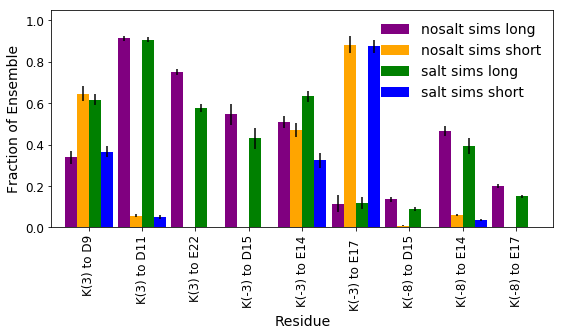

In [23]:
#making plot
plt.rcParams['figure.figsize'] = [9, 4]
ax1 = electrostat_frac_subset_rn[['nosalt sims long', 'nosalt sims short', 'salt sims long', 'salt sims short']].plot.bar(fontsize = 12, width=0.9, color = ['purple','orange', 'green', 'blue'], yerr = electrostat_frac_sem_subset_rn[['nosalt sims long', 'nosalt sims short', 'salt sims long', 'salt sims short']])
ax1.set_ylim(bottom=0, top=1.05)
plt.legend(fontsize = 14, frameon=False)
plt.xlabel('Residue', fontsize = 14)                 
plt.ylabel('Fraction of Ensemble', fontsize = 14)
# plt.title('Contact Between Charged Residues',fontsize = 14)


## The purpose of this code below is to stack the long range over the short range 

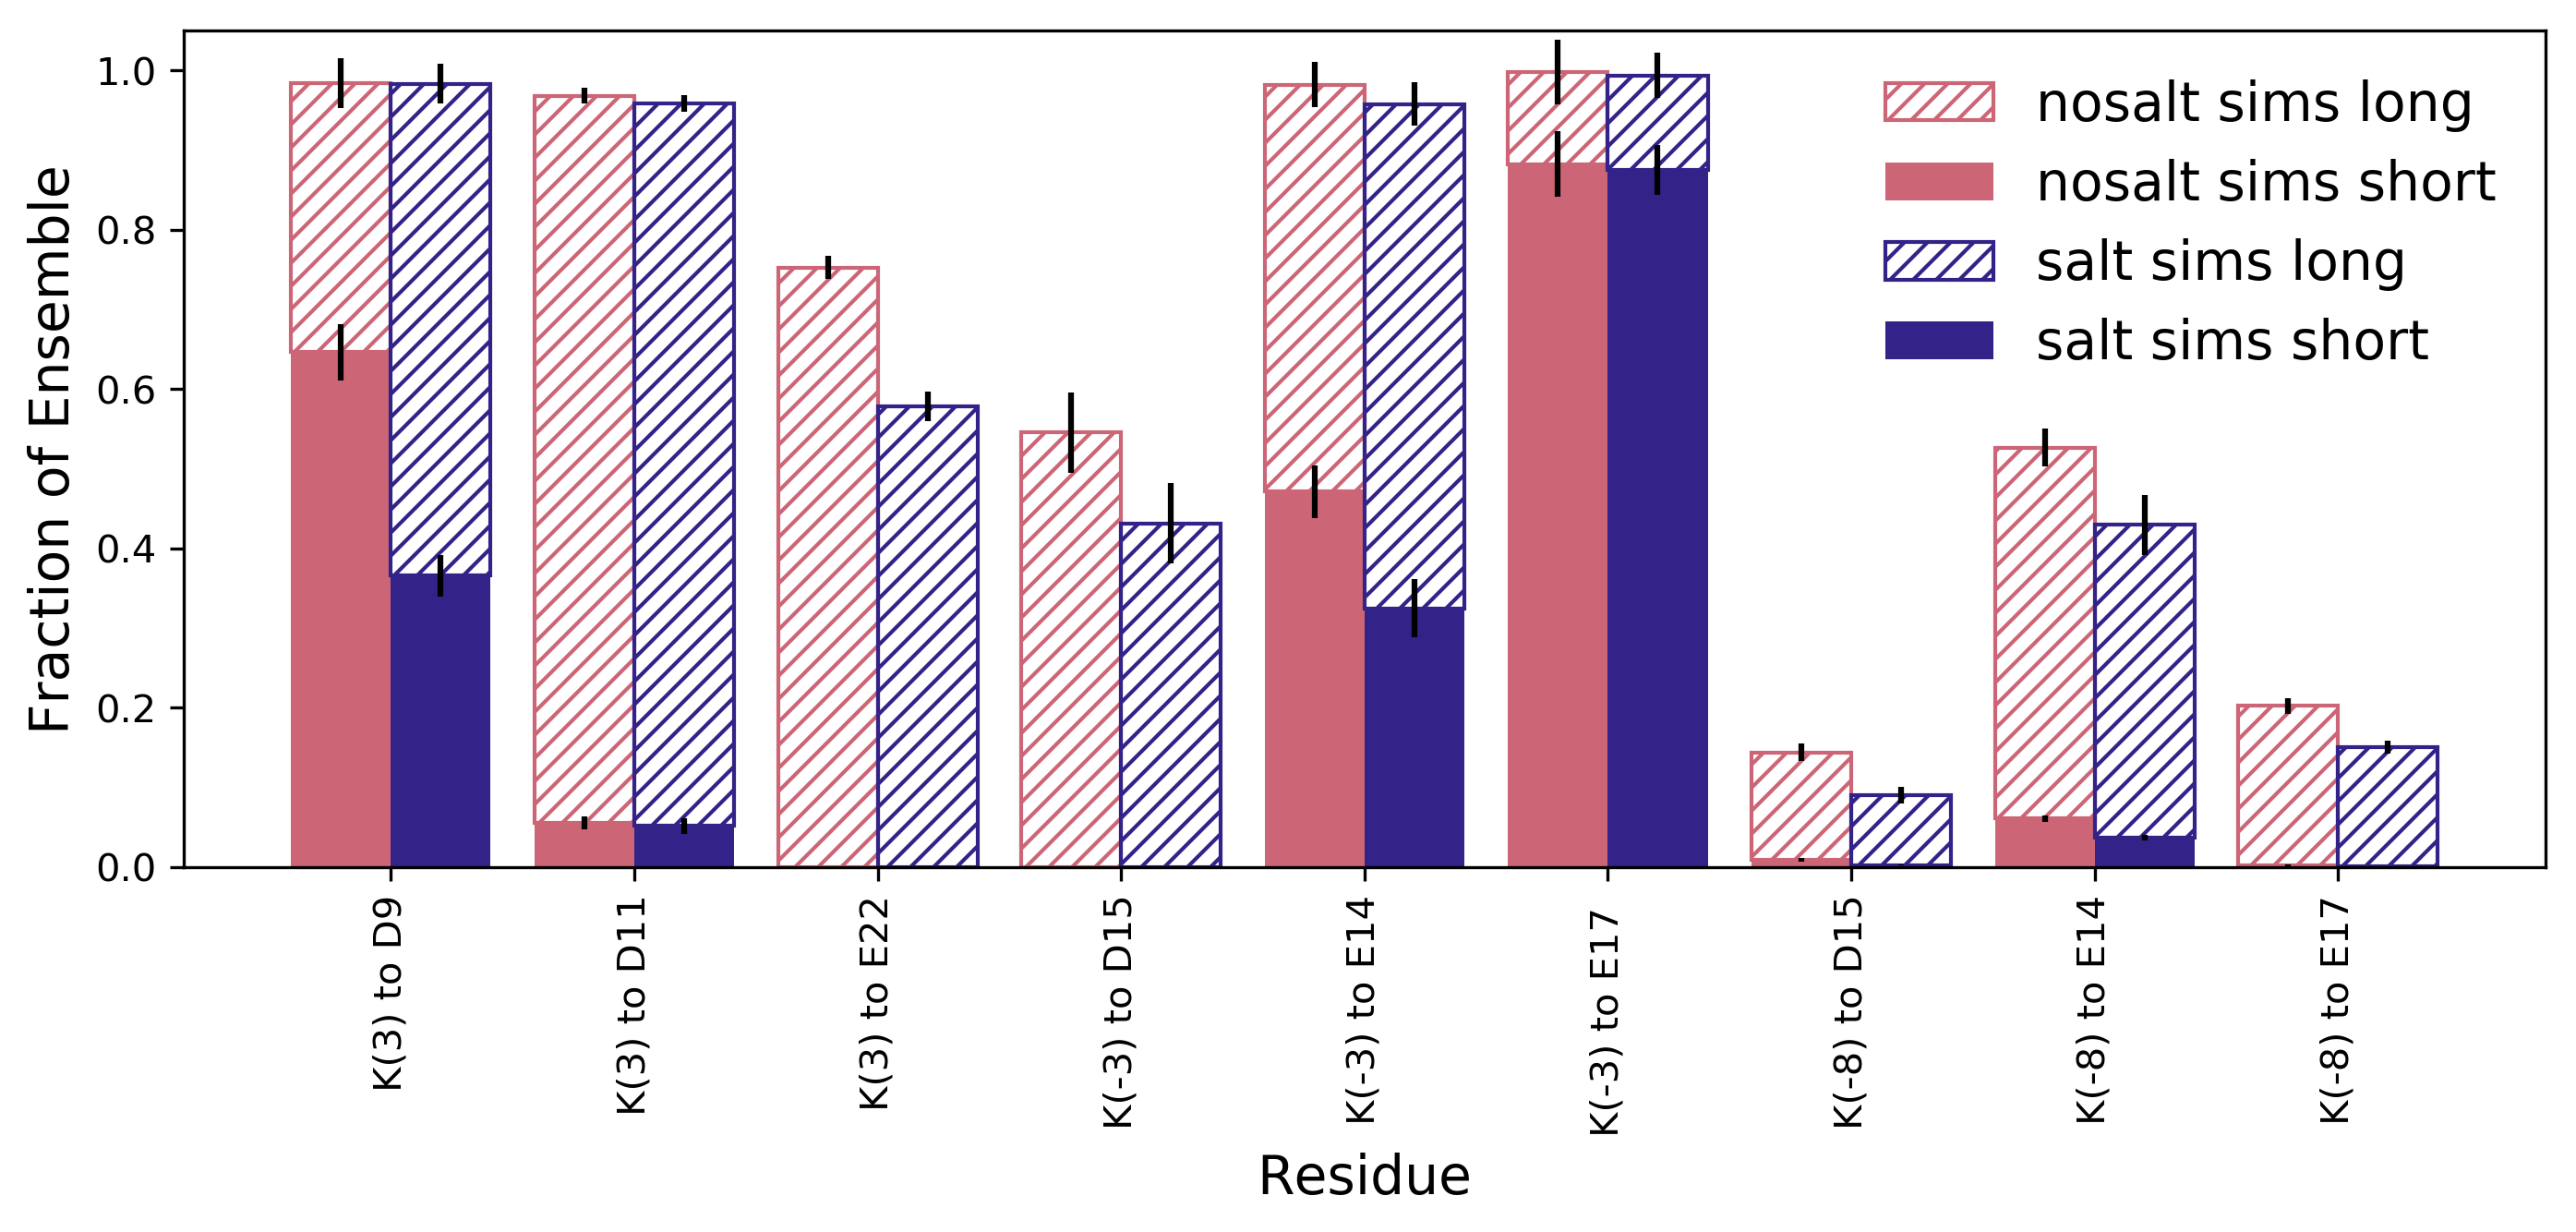

<Figure size 792x288 with 0 Axes>

In [25]:
plt.figure(dpi=300)
plt.rcParams['figure.figsize'] = [11, 4]

# Data
x = np.arange(len(electrostat_frac_subset_rn.index))  # X coordinates for each group
width = 0.41  # Width of the bars

# Plotting the "long" bars (only for "nosalt sims")
plt.bar(x - width/2, electrostat_frac_subset_rn['nosalt sims long'], width, 
        bottom=electrostat_frac_subset_rn['nosalt sims short'], edgecolor='#CC6677', facecolor='none', hatch='////', 
        yerr=electrostat_frac_sem_subset_rn['nosalt sims long'], label='nosalt sims long')

# Plotting the "short" bars (only for "nosalt sims")
plt.bar(x - width/2, electrostat_frac_subset_rn['nosalt sims short'], width, color='#CC6677', 
        yerr=electrostat_frac_sem_subset_rn['nosalt sims short'], label='nosalt sims short')



# Plotting the "long" bars (only for "salt sims")
plt.bar(x + width/2, electrostat_frac_subset_rn['salt sims long'], width, 
        bottom=electrostat_frac_subset_rn['salt sims short'], edgecolor='#332288', facecolor='none', hatch='////', 
        yerr=electrostat_frac_sem_subset_rn['salt sims long'], label='salt sims long')

# Plotting the "short" bars (only for "salt sims")
plt.bar(x + width/2, electrostat_frac_subset_rn['salt sims short'], width, color='#332288', 
        yerr=electrostat_frac_sem_subset_rn['salt sims short'], label='salt sims short')

# Set the y-axis limits
plt.ylim(bottom=0, top=1.05)

# Add legend, xlabel, ylabel, and title
plt.legend(fontsize=14, frameon=False)
plt.xlabel('Residue', fontsize=14)                 
plt.ylabel('Fraction of Ensemble', fontsize=14)
# plt.title('Contact Between Charged Residues', fontsize=14)

# Set x-axis ticks as original index
plt.xticks(x, electrostat_frac_subset_rn.index)

# Rotate x-axis labels for better visibility if needed
plt.xticks(rotation=90)

# Show the plot
plt.show()
plt.savefig("Stacked_electrostats_bound_encounter_ArkA12_with_errbars.png", dpi= 300)

In [1]:
electrostat_frac_sem

NameError: name 'electrostat_frac_sem' is not defined